In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

# Direct URL to the authentic Credit Risk Dataset
DATA_URL = "https://raw.githubusercontent.com/soudhu/Credit-Risk/main/credit_risk_dataset.csv"

print("Downloading and loading dataset...")
df_raw = pd.read_csv(DATA_URL)

print(f"Dataset successfully loaded! Total rows: {df_raw.shape[0]}, Total columns: {df_raw.shape[1]}")
df_raw.head()

Dataset successfully loaded! Total rows: 32581, Total columns: 12


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [13]:
print("--- 1. Data Types & Non-Null Counts ---")
print(df_raw.info())

print("\n--- 2. Missing Values Count per Column ---")
missing = df_raw.isnull().sum()
print(missing[missing > 0])

print("\n--- 3. Summary Statistics for Numerical Columns ---")
df_raw.describe().T[['min', 'mean', '50%', 'max']]

--- 1. Data Types & Non-Null Counts ---
<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB
None



,min,mean,50%,max
person_age,20.00,27.734600,26.00,144.00
person_income,4000.00,66074.848470,55000.00,6000000.00
person_emp_length,0.00,4.789686,4.00,123.00
loan_amnt,500.00,9589.371106,8000.00,35000.00
loan_int_rate,5.42,11.011695,10.99,23.22
loan_status,0.00,0.218164,0.00,1.00
loan_percent_income,0.00,0.170203,0.15,0.83
cb_person_cred_hist_length,2.00,5.804211,4.00,30.00


In [14]:
# 1. Store the initial row count
initial_rows = len(df_raw)

# 2. Filter out physically impossible outliers:
# - A borrower cannot be older than 100 years
# - A borrower cannot have worked more than 60 years (or longer than their age)
df_cleaned = df_raw[
    (df_raw['person_age'] <= 100) & 
    (df_raw['person_emp_length'].isna() | (df_raw['person_emp_length'] <= 60))
].copy()

# Ensure employment length doesn't exceed their age minus 14 (child labor law / realistic threshold)
df_cleaned = df_cleaned[
    df_cleaned['person_emp_length'].isna() | 
    (df_cleaned['person_emp_length'] < (df_cleaned['person_age'] - 14))
]

removed_rows = initial_rows - len(df_cleaned)
print(f"Initial rows: {initial_rows}")
print(f"Removed corrupt/outlier rows: {removed_rows}")
print(f"Cleaned dataset rows: {len(df_cleaned)}")

# --- UNIT TEST / ASSERTIONS (Required for Gate H2) ---
# Mathematically prove the cleaning rules worked:
assert df_cleaned['person_age'].max() <= 100, "Assertion Error: Age > 100 still exists!"
assert df_cleaned['person_emp_length'].max() <= 60, "Assertion Error: Employment length > 60 still exists!"
assert (df_cleaned['person_emp_length'].dropna() >= df_cleaned.loc[df_cleaned['person_emp_length'].notna(), 'person_age']).sum() == 0, \
    "Assertion Error: Someone worked longer than their age!"

print("All cleaning assertions passed successfully!")

Initial rows: 32581
Removed corrupt/outlier rows: 7
Cleaned dataset rows: 32574
All cleaning assertions passed successfully!


In [15]:
# 1. Separate Features (X) and Target (y)
X = df_cleaned.drop(columns=['loan_status'])
y = df_cleaned['loan_status']

# 2. Identify Numerical and Categorical feature columns automatically
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'str', 'category']).columns.tolist()

print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)

# 3. Train/Test Split (80% train, 20% test)
# NOTICE: We split BEFORE fitting any imputer, scaler, or encoder! (Zero Data Leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Testing set:  {X_test.shape[0]} samples")
print(f"Train Default Rate: {y_train.mean():.4f}")
print(f"Test Default Rate:  {y_test.mean():.4f}")

Numerical features: ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']
Categorical features: ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

Training set: 26059 samples
Testing set:  6515 samples
Train Default Rate: 0.2182
Test Default Rate:  0.2181


In [16]:
# 1. Define the Numerical Sub-Pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# 2. Define the Categorical Sub-Pipeline
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# 3. Combine both into a unified ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print("ColumnTransformer successfully constructed!")

# --- UNIT TEST / ASSERTION (Required for Gate H2) ---
# Fit preprocessor ONLY on X_train and transform
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Verify no NaN or infinite values exist in transformed data
assert not np.isnan(X_train_processed).any(), "Assertion Error: Nulls found in processed training data!"
assert not np.isnan(X_test_processed).any(), "Assertion Error: Nulls found in processed testing data!"
assert not np.isinf(X_train_processed).any(), "Assertion Error: Infinite values found in processed data!"

print(f"X_train transformed shape: {X_train_processed.shape}")
print(f"X_test transformed shape:  {X_test_processed.shape}")
print("Assertion Passed: Exactly ZERO nulls or invalid values in the preprocessed feature matrix!")

ColumnTransformer successfully constructed!
X_train transformed shape: (26059, 26)
X_test transformed shape:  (6515, 26)
Assertion Passed: Exactly ZERO nulls or invalid values in the preprocessed feature matrix!


In [17]:
# 1. Assemble the full end-to-end pipeline: Preprocessor + Estimator
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100, 
        max_depth=12,
        random_state=42, 
        n_jobs=-1
    ))
])

print("Training the end-to-end Pipeline on X_train...")

# 2. Fit the entire pipeline in ONE single call!
# This automatically fits the preprocessor AND trains the Random Forest
full_pipeline.fit(X_train, y_train)

print("Pipeline training completed successfully!")

Training the end-to-end Pipeline on X_train...
Pipeline training completed successfully!


Overall Accuracy:  0.9297 (92.97%)
ROC-AUC Score:     0.9220

--- Classification Report ---
                precision    recall  f1-score   support

No Default (0)       0.92      1.00      0.96      5094
   Default (1)       0.98      0.69      0.81      1421

      accuracy                           0.93      6515
     macro avg       0.95      0.84      0.88      6515
  weighted avg       0.93      0.93      0.93      6515



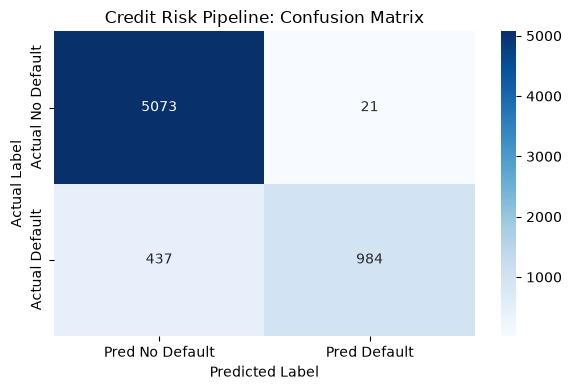

In [18]:
# 1. Generate predictions on the unseen test set (X_test)
# The full_pipeline automatically transforms X_test and predicts!
y_pred = full_pipeline.predict(X_test)
y_pred_proba = full_pipeline.predict_proba(X_test)[:, 1]

# 2. Compute key evaluation metrics
acc = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("=" * 55)
print(f"Overall Accuracy:  {acc:.4f} ({acc*100:.2f}%)")
print(f"ROC-AUC Score:     {roc_auc:.4f}")
print("=" * 55)

# 3. Detailed Classification Report (Precision, Recall, F1)
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['No Default (0)', 'Default (1)']))

# 4. Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Pred No Default', 'Pred Default'],
            yticklabels=['Actual No Default', 'Actual Default'])
plt.title('Credit Risk Pipeline: Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

In [19]:
# Create two simulated new loan applicants with raw, un-preprocessed data
# Notice Applicant 2 has missing values (np.nan) in employment length and interest rate!
new_applicants = pd.DataFrame([
    {
        'person_age': 28,
        'person_income': 95000,
        'person_home_ownership': 'MORTGAGE',
        'person_emp_length': 6.0,
        'loan_intent': 'VENTURE',
        'loan_grade': 'A',
        'loan_amnt': 8000,
        'loan_int_rate': 7.90,
        'loan_percent_income': 0.08,
        'cb_person_default_on_file': 'N',
        'cb_person_cred_hist_length': 6
    },
    {
        'person_age': 21,
        'person_income': 18000,
        'person_home_ownership': 'RENT',
        'person_emp_length': np.nan,       # Missing value!
        'loan_intent': 'DEBTCONSOLIDATION',
        'loan_grade': 'D',
        'loan_amnt': 15000,
        'loan_int_rate': np.nan,          # Missing value!
        'loan_percent_income': 0.83,       # Loan is 83% of annual income!
        'cb_person_default_on_file': 'Y',
        'cb_person_cred_hist_length': 2
    }
])

# Pass raw DataFrame directly through the pipeline!
predictions = full_pipeline.predict(new_applicants)
probabilities = full_pipeline.predict_proba(new_applicants)

print("=== Live Inference on New Raw Applicants ===")
for i, (pred, prob) in enumerate(zip(predictions, probabilities)):
    status = "APPROVED / NO DEFAULT" if pred == 0 else "HIGH RISK / DEFAULT"
    risk_score = prob[1] * 100
    print(f"\nApplicant {i + 1}:")
    print(f"- Decision:    {status}")
    print(f"- Default Risk: {risk_score:.2f}%")

# Assertions to ensure predictions are valid
assert len(predictions) == 2, "Assertion Error: Prediction count mismatch!"
assert set(predictions).issubset({0, 1}), "Assertion Error: Invalid prediction classes!"
print("\nFinal Pipeline Inference Assertion: PASSED!")

=== Live Inference on New Raw Applicants ===

Applicant 1:
- Decision:    APPROVED / NO DEFAULT
- Default Risk: 0.60%

Applicant 2:
- Decision:    HIGH RISK / DEFAULT
- Default Risk: 99.00%

Final Pipeline Inference Assertion: PASSED!
